In [1]:
import sys, os
from utils import * 


In [2]:
import joblib

DATASET_NAME, X_train, X_test, y_train, y_test = joblib.load("ULB_data.pkl")
y_test = y_test.values.ravel()

MODEL_NAME = "Autoencoder"
DE_LONG_RESULTS = "ULB_all_results.pkl"
METRICS = "ULB_metrics.pkl"


In [3]:
# ======================================================
# ======================================================
# ======================================================
# ======================================================
# ======================================================
# =================== 4. AUTOENCODER ===================
# ======================================================
# ======================================================
# ======================================================
# ======================================================
# ======================================================

In [4]:
# ===================== 4. AUTOENCODER =====================
AE_train_scores, AE_test_scores, AE_model = run_autoencoder(X_train, X_test, epochs=AE_EPOCHS, batch_size=AE_BATCH_SIZE)


Epoch 1/20
6908/6908 ━━━━━━━━━━━━━━━━━━━━ 95s 13ms/step - loss: 0.5497 - val_loss: 0.3657
Epoch 2/20
6908/6908 ━━━━━━━━━━━━━━━━━━━━ 98s 14ms/step - loss: 0.3635 - val_loss: 0.3584
Epoch 3/20
6908/6908 ━━━━━━━━━━━━━━━━━━━━ 81s 12ms/step - loss: 0.3585 - val_loss: 0.3574
Epoch 4/20
6908/6908 ━━━━━━━━━━━━━━━━━━━━ 99s 14ms/step - loss: 0.3581 - val_loss: 0.3572
Epoch 5/20
6908/6908 ━━━━━━━━━━━━━━━━━━━━ 89s 13ms/step - loss: 0.3578 - val_loss: 0.3571
Epoch 6/20
6908/6908 ━━━━━━━━━━━━━━━━━━━━ 73s 11ms/step - loss: 0.3577 - val_loss: 0.3571
Epoch 7/20
6908/6908 ━━━━━━━━━━━━━━━━━━━━ 93s 13ms/step - loss: 0.3573 - val_loss: 0.3570
Epoch 8/20
6908/6908 ━━━━━━━━━━━━━━━━━━━━ 90s 13ms/step - loss: 0.3576 - val_loss: 0.3570
Epoch 9/20
6908/6908 ━━━━━━━━━━━━━━━━━━━━ 95s 14ms/step - loss: 0.3578 - val_loss: 0.3570
Epoch 10/20
6908/6908 ━━━━━━━━━━━━━━━━━━━━ 136s 13ms/step - loss: 0.3576 - val_loss: 0.3570
Epoch 11/20
6908/6908 ━━━━━━━━━━━━━━━━━━━━ 106s 15ms/step - loss: 0.3579 - val_loss: 0.3570
Epoch 

In [11]:
# ===================== Store metrics =====================
AE_metrics = store_anomaly_metrics(y_true=y_test, scores=-AE_test_scores, dataset_name=DATASET_NAME, model_name=MODEL_NAME)
display(AE_metrics)


,Model,Data,Precision,Precision_CI,Recall,Recall_CI,F1,F1_CI,ROC_AUC,ROC_AUC_CI,PR_AUC,PR_AUC_CI,Confusion_Matrix,Threshold
0,Autoencoder,creditcard,0.00351,0.001-0.006,0.102041,0.046-0.168,0.006787,0.003-0.012,0.695263,0.639-0.749,0.003838,0.003-0.005,"[[54025, 2839], [88, 10]]",-0.125818


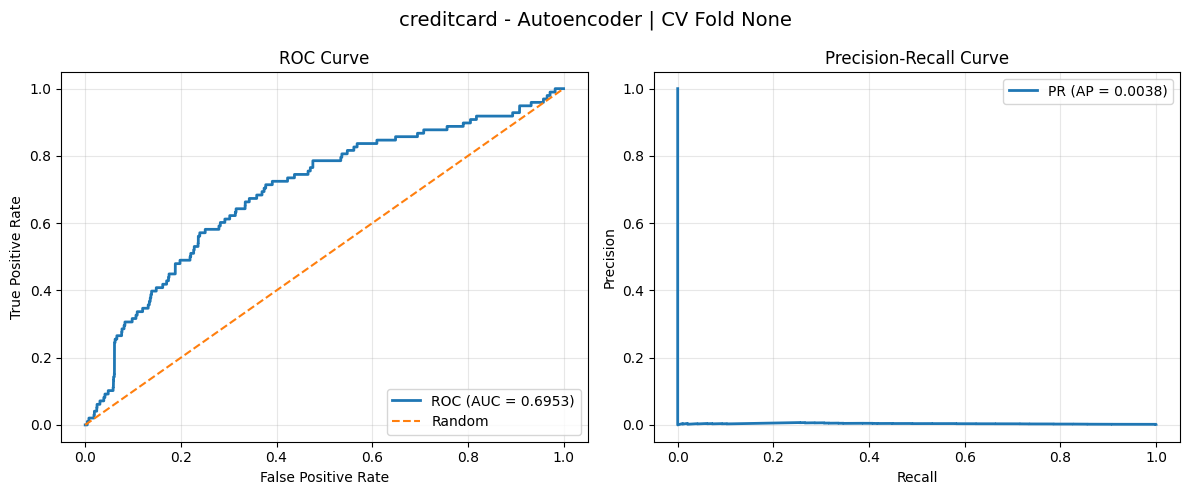

In [15]:
# ===================== Plot results =====================
plot_anomaly_roc_pr(y_true=y_test, scores=-AE_test_scores, dataset_name=DATASET_NAME, model_name=MODEL_NAME)


In [8]:
# ===================== Fit on CV folds =====================
AE_cv_results = fit_cross_validate(X_train, y_train, X_test, y_test, run_autoencoder, DATASET_NAME, MODEL_NAME, CV_FOLDS, RANDOM_STATE)


Epoch 1/20
5526/5526 ━━━━━━━━━━━━━━━━━━━━ 79s 13ms/step - loss: 0.5478 - val_loss: 0.3708
Epoch 2/20
5526/5526 ━━━━━━━━━━━━━━━━━━━━ 72s 13ms/step - loss: 0.3667 - val_loss: 0.3603
Epoch 3/20
5526/5526 ━━━━━━━━━━━━━━━━━━━━ 58s 10ms/step - loss: 0.3591 - val_loss: 0.3583
Epoch 4/20
5526/5526 ━━━━━━━━━━━━━━━━━━━━ 42s 8ms/step - loss: 0.3586 - val_loss: 0.3577
Epoch 5/20
5526/5526 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - loss: 0.3585 - val_loss: 0.3574
Epoch 6/20
5526/5526 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - loss: 0.3578 - val_loss: 0.3573
Epoch 7/20
5526/5526 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - loss: 0.3569 - val_loss: 0.3572
Epoch 8/20
5526/5526 ━━━━━━━━━━━━━━━━━━━━ 26s 5ms/step - loss: 0.3576 - val_loss: 0.3572
Epoch 9/20
5526/5526 ━━━━━━━━━━━━━━━━━━━━ 26s 5ms/step - loss: 0.3571 - val_loss: 0.3571
Epoch 10/20
5526/5526 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - loss: 0.3569 - val_loss: 0.3571
Epoch 11/20
5526/5526 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step - loss: 0.3576 - val_loss: 0.3571
Epoch 12/20
5526

In [9]:
# ===================== Store CV metrics =====================

AE_cv_metrics = pd.concat([r["test_metrics"] for r in AE_cv_results], ignore_index=True)
display(AE_cv_metrics)



,Model,Data,Precision,Precision_CI,Recall,Recall_CI,F1,F1_CI,ROC_AUC,ROC_AUC_CI,PR_AUC,PR_AUC_CI,Confusion_Matrix,Threshold
0,Autoencoder_Fold1,creditcard,0.001404,0.000-0.003,0.040816,0.009-0.084,0.002715,0.001-0.006,0.303971,0.250-0.360,0.001185,0.001-0.002,"[[54019, 2845], [94, 4]]",0.551968
1,Autoencoder_Fold2,creditcard,0.001404,0.000-0.003,0.040816,0.009-0.084,0.002715,0.001-0.006,0.305143,0.252-0.361,0.001187,0.001-0.002,"[[54019, 2845], [94, 4]]",0.551935
2,Autoencoder_Fold3,creditcard,0.001404,0.000-0.003,0.040816,0.009-0.084,0.002715,0.001-0.006,0.304755,0.251-0.360,0.001187,0.001-0.002,"[[54019, 2845], [94, 4]]",0.551945
3,Autoencoder_Fold4,creditcard,0.001404,0.000-0.003,0.040816,0.009-0.084,0.002715,0.001-0.006,0.303917,0.250-0.360,0.001185,0.001-0.002,"[[54019, 2845], [94, 4]]",0.551915
4,Autoencoder_Fold5,creditcard,0.001404,0.000-0.003,0.040816,0.009-0.084,0.002715,0.001-0.006,0.305489,0.251-0.361,0.001187,0.001-0.002,"[[54019, 2845], [94, 4]]",0.551852


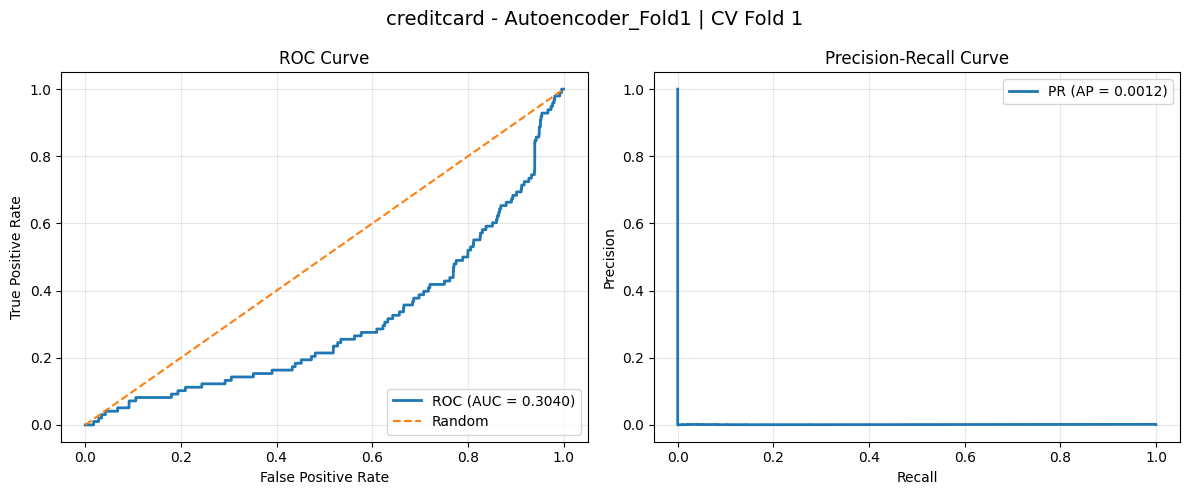

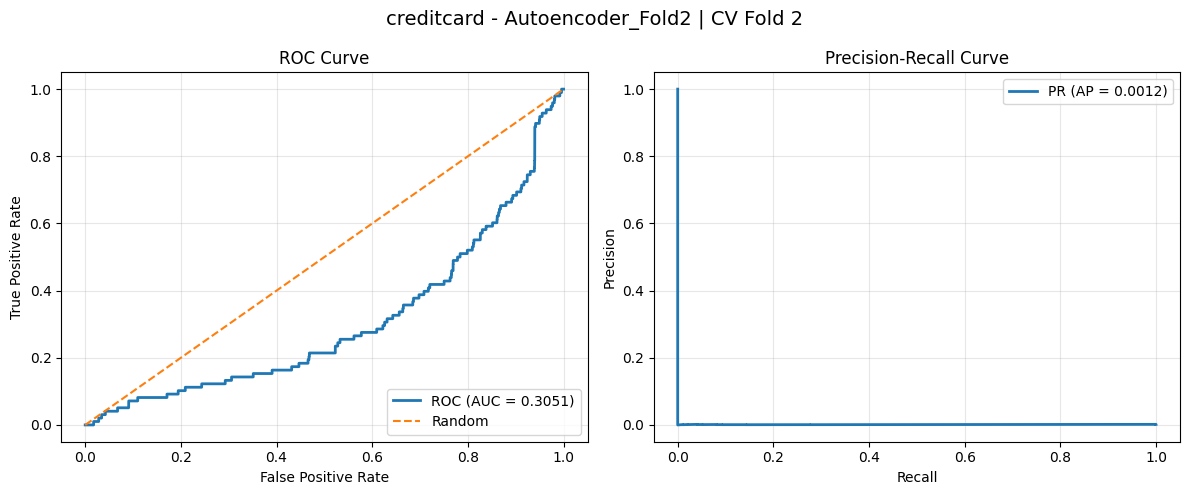

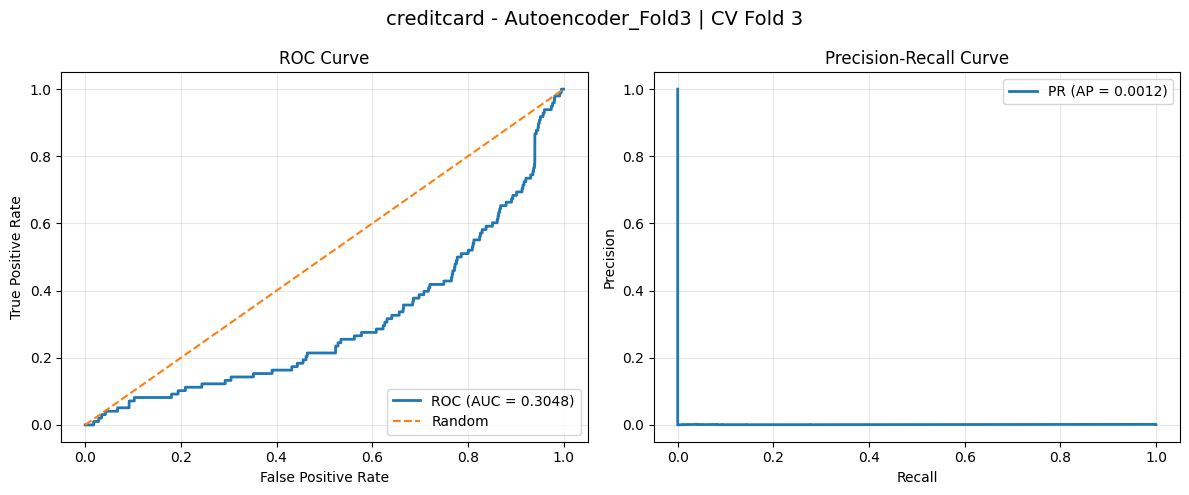

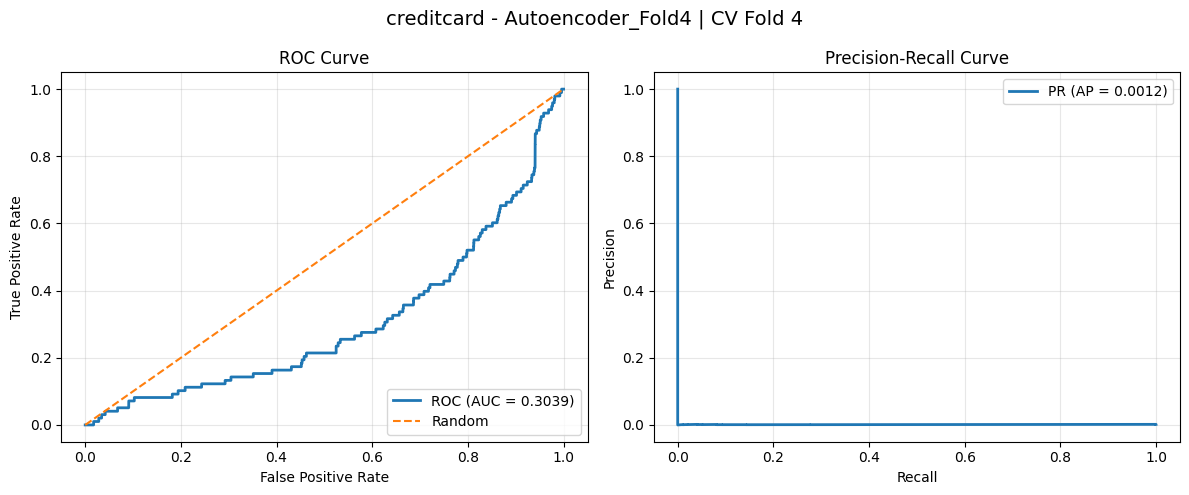

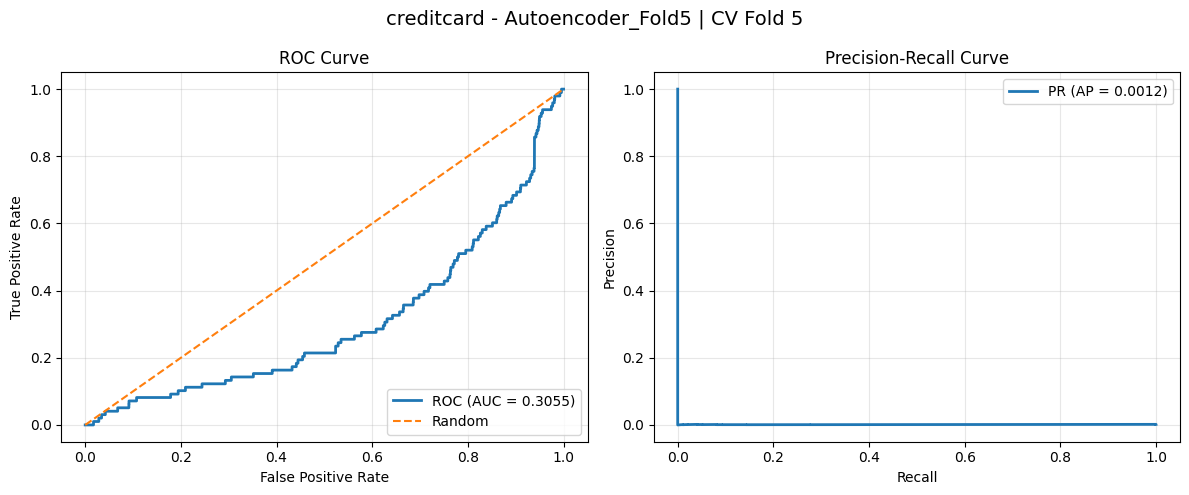

In [10]:
# ===================== Plot CV results =====================

for r in AE_cv_results:
    plot_anomaly_roc_pr(y_test, r["test_scores"], DATASET_NAME, f"{MODEL_NAME}_Fold{r['fold']}", r["fold"])


In [16]:
if os.path.exists(DE_LONG_RESULTS):
    results = joblib.load(DE_LONG_RESULTS)
else:
    results = {}

results[MODEL_NAME] = {
    "test_scores": -AE_test_scores,
    "auc": roc_auc_score(y_test, -AE_test_scores)
}

joblib.dump(results, DE_LONG_RESULTS)

['ULB_all_results.pkl']

In [14]:
if os.path.exists(METRICS):
    results = joblib.load(METRICS)
else:
    results = {}

results[MODEL_NAME] = {
    "metrics": AE_metrics,
    "cv_metrics": AE_cv_results
}

joblib.dump(results, METRICS)

['ULB_metrics.pkl']